In [1]:
import pandas as pd
from pathlib import Path
import re
import json
from sklearn.metrics import classification_report, confusion_matrix, multilabel_confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
 
llm_results_path = Path("llm_results_public")
results_path = Path("results")

def load_results(model_name: str) -> pd.DataFrame:
    file_path = llm_results_path / f"PANDEIA_RESULTS_{model_name}_fewshot.csv"
    return pd.read_csv(file_path)

manual_labeling_dataset_path = llm_results_path / "PANDEIA_DATASET_ManualLabeling_Final.csv"

manual_labeling_dataset = pd.read_csv(manual_labeling_dataset_path)

manual_labeling_dataset = manual_labeling_dataset[
    manual_labeling_dataset['IS_DEIA?'] == "yes"
]

figures_path = Path("figures")
os.makedirs(figures_path, exist_ok=True)

subthemes = ["gender","race","lgbtq+","disability", "none"]

In [2]:
manual_labeling_dataset.columns 

Index(['ID', 'Date', 'Subreddit', 'Permalink', 'Score', 'num_comment',
       'DEIA?_x', 'KeyWords_x', 'SubTheme_x', 'Position_x',
       'Confidence level_x', 'Justification_x', 'DEIA?_y', 'KeyWords_y',
       'SubTheme_y', 'Position_y', 'Confidence level_y', 'Justification_y',
       'IS_DEIA?', 'Agreement_Polarization', 'Agreement_Subthemes'],
      dtype='str')

In [3]:
subthemes = ["gender", "disability", "lgbtq+", "race", "none"]

parsed = (
    manual_labeling_dataset["Agreement_Subthemes"]
    .fillna("")
    .str.split(",")
    .apply(lambda x: [i.strip() for i in x])
)

for s in subthemes:
    manual_labeling_dataset[s] = parsed.apply(lambda x: s in x)

In [4]:
manual_labeling_dataset["Date"] = pd.to_datetime(manual_labeling_dataset["Date"])

polarization_time = (
    manual_labeling_dataset
    .groupby([pd.Grouper(key="Date", freq="ME"), "Agreement_Polarization"])
    .size()
    .unstack(fill_value=0)
)

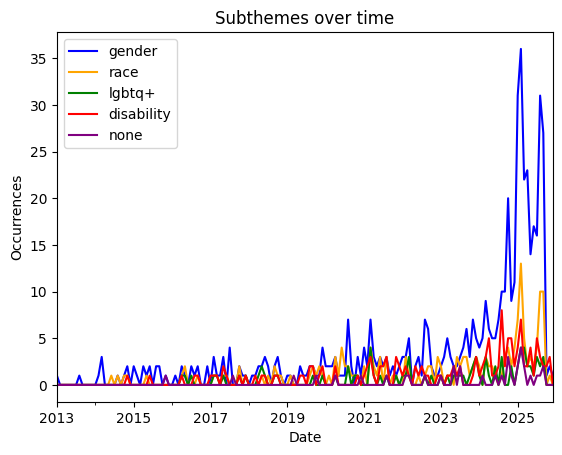

In [5]:
subtheme_time = (
    manual_labeling_dataset
    .set_index("Date")[["gender","race","lgbtq+","disability", "none"]]
    .resample("ME")
    .sum()
)

subtheme_time.plot(color=["blue", "orange", "green", "red", "purple"])
plt.title("Subthemes over time")
plt.ylabel("Occurrences")
plt.show()

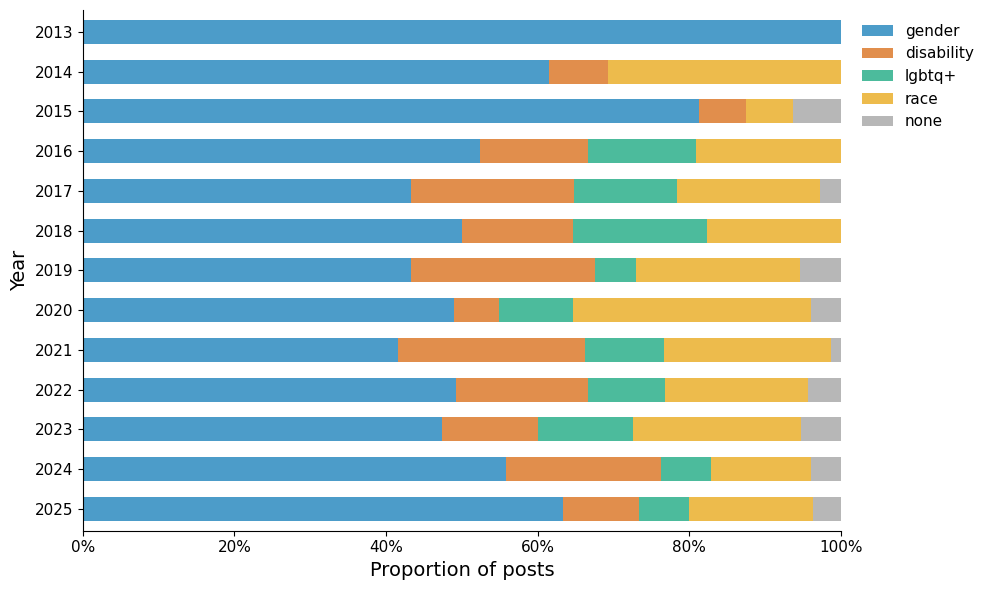

In [6]:
subthemes_time = (
    manual_labeling_dataset
    .set_index("Date")
    .resample("YE")[subthemes]
    .sum()
)

subthemes_pct = subthemes_time.div(
    subthemes_time.sum(axis=1),
    axis=0
)

colors = {
    "gender": "#0072B2",
    "race": "#E69F00",
    "lgbtq+": "#009E73",
    "disability": "#D55E00",
    "none": "#999999"
}

# Inverter ordem dos anos (mais recente no topo)
subthemes_pct = subthemes_pct.iloc[::-1]

# Formatar o índice só com o ano
subthemes_pct.index = subthemes_pct.index.year

ax = subthemes_pct.plot(
    kind="barh",          # <-- horizontal
    stacked=True,
    figsize=(10, 6),
    color=[colors[c] for c in subthemes],
    width=0.6,
    alpha=0.7
)

plt.xticks(rotation=0)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

plt.ylabel("Year", fontdict={"size": 14})
plt.xlabel("Proportion of posts", fontdict={"size": 14})
ax.set_xlim(0, 1)

# Formatar eixo X como porcentagem
ax.xaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(xmax=1)
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(fontsize=11, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
plt.tight_layout()

plt.savefig(figures_path / "subthemes_over_time.pdf", dpi=600)
plt.show()

In [7]:
def plot_posts_per_year(df):
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])

    posts_time = df.set_index("Date").resample("W").size()

    yearly = posts_time.groupby(posts_time.index.year)

    years = sorted(yearly.groups.keys())

    fig, axes = plt.subplots(len(years), 1, figsize=(10, 3 * len(years)), sharex=False)

    if len(years) == 1:
        axes = [axes]

    for ax, year in zip(axes, years):

        data = yearly.get_group(year)

        ax.plot(data.index, data.values)

        ax.set_title(f"Posts per Week — {year}")
        ax.set_ylabel("Posts")

    axes[-1].set_xlabel("Week")

    plt.tight_layout()
    plt.show()

# plot_posts_per_year(manual_labeling_dataset)

In [8]:
manual_labeling_dataset.columns

Index(['ID', 'Date', 'Subreddit', 'Permalink', 'Score', 'num_comment',
       'DEIA?_x', 'KeyWords_x', 'SubTheme_x', 'Position_x',
       'Confidence level_x', 'Justification_x', 'DEIA?_y', 'KeyWords_y',
       'SubTheme_y', 'Position_y', 'Confidence level_y', 'Justification_y',
       'IS_DEIA?', 'Agreement_Polarization', 'Agreement_Subthemes', 'gender',
       'disability', 'lgbtq+', 'race', 'none'],
      dtype='str')

## RQ3 - Polarization Analysis

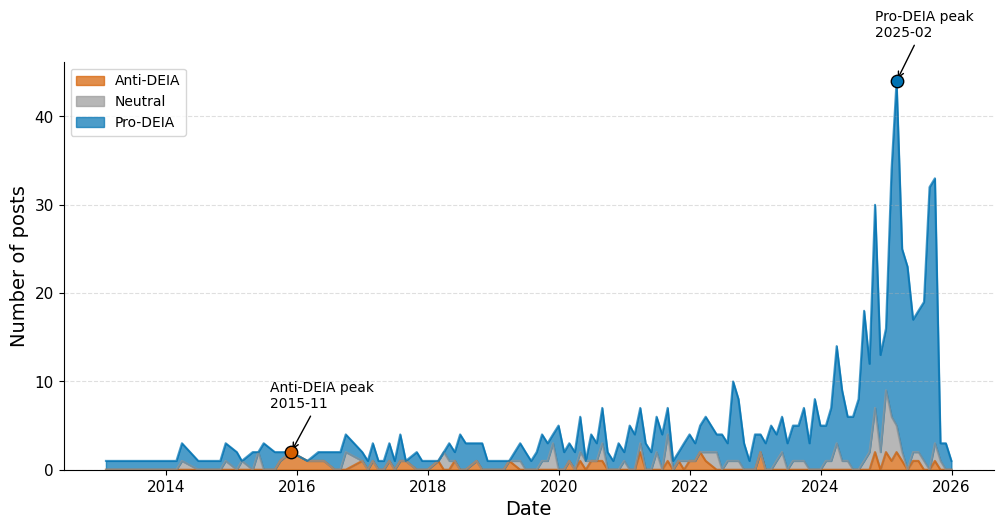

In [9]:
manual_labeling_dataset["Date"] = pd.to_datetime(manual_labeling_dataset["Date"])

polarization_time = (
    manual_labeling_dataset
    .groupby([pd.Grouper(key="Date", freq="ME"), "Agreement_Polarization"])
    .size()
    .unstack(fill_value=0)
)

# garantir ordem consistente das colunas
polarization_time = polarization_time[["Anti-DEIA", "Neutral", "Pro-DEIA"]]

# picos
peak_date_pro = polarization_time["Pro-DEIA"].idxmax()
peak_value_pro = polarization_time["Pro-DEIA"].max()

peak_date_anti = polarization_time["Anti-DEIA"].idxmax()
peak_value_anti = polarization_time["Anti-DEIA"].max()

ax = polarization_time.plot.area(
    color=["#D55E00", "#999999", "#0072B2"],
    alpha=0.7,
    figsize=(12, 6)
)

# posição vertical correta no stacked area
y_pro = polarization_time.loc[peak_date_pro].sum()
y_anti = polarization_time.loc[peak_date_anti, "Anti-DEIA"]

# pontos nos picos
ax.scatter(
    peak_date_pro,
    y_pro,
    color="#0072B2",
    edgecolor="black",
    zorder=5,
    s=80,
    # label="Peak Pro-DEIA"
)

ax.scatter(
    peak_date_anti,
    y_anti,
    color="#D55E00",
    edgecolor="black",
    zorder=5,
    s=80,
    # label="Peak Anti-DEIA"
)

# anotações
ax.annotate(
    f"Pro-DEIA peak\n{peak_date_pro.strftime('%Y-%m')}",
    xy=(peak_date_pro, y_pro),
    xytext=(peak_date_pro - pd.Timedelta(days=120), y_pro + 5),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

ax.annotate(
    f"Anti-DEIA peak\n{peak_date_anti.strftime('%Y-%m')}",
    xy=(peak_date_anti, y_anti),
    xytext=(peak_date_anti - pd.Timedelta(days=120), y_anti + 5),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.xticks(rotation=0)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

for label in ax.get_xticklabels():
    label.set_ha("center")

plt.ylabel("Number of posts", fontdict={"size": 14})
plt.xlabel("Date", fontdict={"size": 14})

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend()

plt.savefig(
    figures_path / "polarization_over_time.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

C:\Users\mario\AppData\Local\Temp\ipykernel_4320\3272672312.py:84: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  month_index = polarization_time.index.to_period("M")


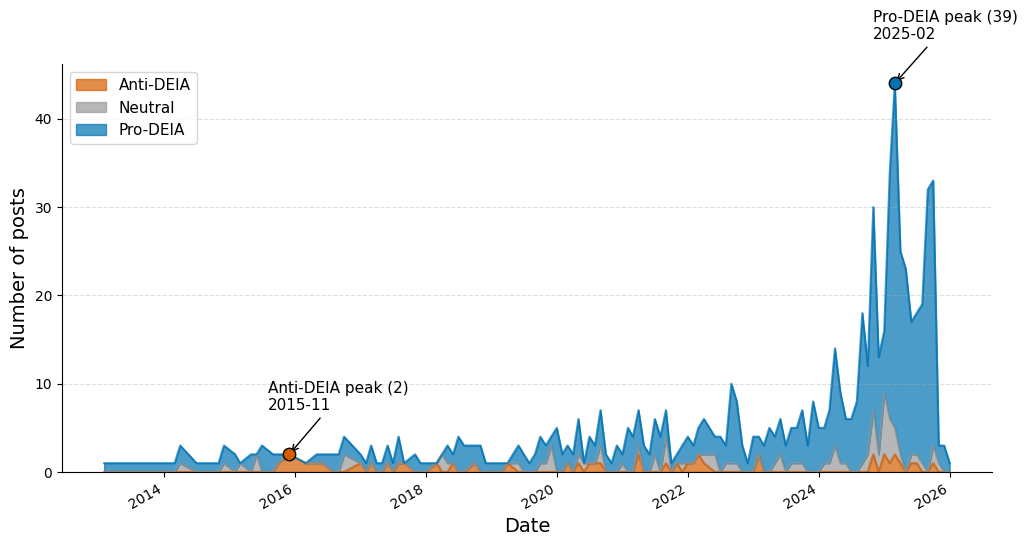

In [10]:
import pandas as pd

manual_labeling_dataset["Date"] = pd.to_datetime(manual_labeling_dataset["Date"], utc=True)

polarization_time = (
    manual_labeling_dataset
    .groupby([pd.Grouper(key="Date", freq="ME"), "Agreement_Polarization"])
    .size()
    .unstack(fill_value=0)
)

polarization_time = polarization_time[["Anti-DEIA", "Neutral", "Pro-DEIA"]]

# picos
peak_date_pro = polarization_time["Pro-DEIA"].idxmax()
peak_value_pro = polarization_time["Pro-DEIA"].max()

peak_date_anti = polarization_time["Anti-DEIA"].idxmax()
peak_value_anti = polarization_time["Anti-DEIA"].max()

ax = polarization_time.plot.area(
    color=["#D55E00", "#999999", "#0072B2"],
    alpha=0.7,
    figsize=(12, 6)
)

# posição vertical correta no stacked area
y_pro = polarization_time.loc[peak_date_pro].sum()
y_anti = polarization_time.loc[peak_date_anti, "Anti-DEIA"]

# pontos nos picos
ax.scatter(
    peak_date_pro,
    y_pro,
    color="#0072B2",
    edgecolor="black",
    zorder=5,
    s=80,
    # label="Peak Pro-DEIA"
)

ax.scatter(
    peak_date_anti,
    y_anti,
    color="#D55E00",
    edgecolor="black",
    zorder=5,
    s=80,
    # label="Peak Anti-DEIA"
)

# anotações
ax.annotate(
    f"Pro-DEIA peak ({peak_value_pro})\n{peak_date_pro.strftime('%Y-%m')}",
    xy=(peak_date_pro, y_pro),
    xytext=(peak_date_pro - pd.Timedelta(days=120), y_pro + 5),
    arrowprops=dict(arrowstyle="->"),
    fontsize=11
)

ax.annotate(
    f"Anti-DEIA peak ({peak_value_anti})\n{peak_date_anti.strftime('%Y-%m')}",
    xy=(peak_date_anti, y_anti),
    xytext=(peak_date_anti - pd.Timedelta(days=120), y_anti + 5),
    arrowprops=dict(arrowstyle="->"),
    fontsize=11
)

pro_dates = [
    # "2024-05-10",
    # "2025-01-20"
]

anti_dates = [
    # "2024-08-12",
    # "2025-01-22"
]

# datas que você quer marcar
pro_dates = pd.to_datetime(pro_dates)
anti_dates = pd.to_datetime(anti_dates)

# índice mensal do gráfico
month_index = polarization_time.index.to_period("M")

# pontos Pro-DEIA
for d in pro_dates:

    period = d.to_period("M")

    if period in month_index:

        d_month = polarization_time.index[month_index == period][0]
        y = polarization_time.loc[d_month].sum()

        ax.scatter(
            d_month,
            y,
            color="#0072B2",
            edgecolor="black",
            s=80,
            zorder=5
        )

        ax.annotate(
            d_month.strftime("%Y-%m"),
            xy=(d_month, y),
            xytext=(d_month - pd.Timedelta(days=90), y + 3),
            fontsize=11,
            arrowprops=dict(arrowstyle="->")
        )

# pontos Anti-DEIA
for d in anti_dates:

    period = d.to_period("M")

    if period in month_index:

        d_month = polarization_time.index[month_index == period][0]
        y = polarization_time.loc[d_month, "Anti-DEIA"]

        ax.scatter(
            d_month,
            y,
            color="#D55E00",
            edgecolor="black",
            s=80,
            zorder=5
        )

        ax.annotate(
            d_month.strftime("%Y-%m"),
            xy=(d_month, y),
            xytext=(d_month - pd.Timedelta(days=90), y + 3),
            fontsize=11,
            arrowprops=dict(arrowstyle="->")
        )

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.ylabel("Number of posts", fontsize=14)
plt.xlabel("Date", fontsize=14)
ax.legend(fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig(figures_path / "polarization_over_time.pdf", dpi=600, bbox_inches="tight")
plt.show()

### Before x After Analysis

In [11]:
policy_date = pd.Timestamp("2025-01-20", tz="UTC")

before = manual_labeling_dataset[
    manual_labeling_dataset["Date"] < policy_date
]

after = manual_labeling_dataset[
    manual_labeling_dataset["Date"] >= policy_date
]

In [12]:
before_polarization = before.groupby("Agreement_Polarization").size()
after_polarization = after.groupby("Agreement_Polarization").size()

before_column = before_polarization / before_polarization.sum()
after_column = after_polarization / after_polarization.sum()

index = before_column.index 
columns = ["Before Policy", "After Policy"]

polarization_comparison = pd.DataFrame({
    "Before Policy (%)": before_column.round(2) * 100,
    "After Policy (%)": after_column.round(2) * 100
}, index=index)

print(polarization_comparison.T)

Agreement_Polarization  Anti-DEIA  Neutral  Pro-DEIA
Before Policy (%)             8.0     15.0      78.0
After Policy (%)              3.0      5.0      93.0


In [13]:
before_polarization = before.groupby("Agreement_Polarization").size()
after_polarization = after.groupby("Agreement_Polarization").size()

before_pol = before.groupby("Agreement_Polarization").size()
after_pol = after.groupby("Agreement_Polarization").size()

index = before_column.index 
columns = ["Before Policy", "After Policy"]

polarization_comparison = pd.DataFrame({
    "Before Policy (%)": before_column.round(2) * 100,
    "After Policy (%)": after_column.round(2) * 100
}, index=index)

polarization_comparison = polarization_comparison.div(
    polarization_comparison.sum(axis=1),
    axis=0
)

print(polarization_comparison)

                        Before Policy (%)  After Policy (%)
Agreement_Polarization                                     
Anti-DEIA                        0.727273          0.272727
Neutral                          0.750000          0.250000
Pro-DEIA                         0.456140          0.543860


### Anti X Pro

In [14]:
polarization_time = (
    manual_labeling_dataset
    .groupby([pd.Grouper(key="Date", freq="ME"), "Agreement_Polarization"])
    .size()
    .unstack(fill_value=0)
)

polarization_pct = polarization_time.div(
    polarization_time.sum(axis=1), axis=0
) * 100

### Before vs During vs After

In [15]:
# garantir que a coluna Date esteja em datetime UTC
manual_labeling_dataset["Date"] = pd.to_datetime(
    manual_labeling_dataset["Date"], utc=True
)

# data da política
policy_date = pd.Timestamp("2025-01-20", tz="UTC")

# janela do período "during" (±7 dias)
window_days = 7

during_start = policy_date - pd.Timedelta(days=window_days)
during_end = policy_date + pd.Timedelta(days=window_days)

# separar os períodos
before = manual_labeling_dataset[
    manual_labeling_dataset["Date"] < during_start
]

during = manual_labeling_dataset[
    (manual_labeling_dataset["Date"] >= during_start) &
    (manual_labeling_dataset["Date"] <= during_end)
]

after = manual_labeling_dataset[
    manual_labeling_dataset["Date"] > during_end
]

# contagem por polarização
before_pol = before.groupby("Agreement_Polarization").size()
during_pol = during.groupby("Agreement_Polarization").size()
after_pol = after.groupby("Agreement_Polarization").size()

# converter para proporção
before_pct = before_pol / before_pol.sum()
during_pct = during_pol / during_pol.sum()
after_pct = after_pol / after_pol.sum()

# unir os índices (caso alguma polarização não apareça em algum período)
index = sorted(set(before_pct.index) | set(during_pct.index) | set(after_pct.index))

polarization_comparison = pd.DataFrame({
    "Before Policy (%)": before_pct.round(2) * 100,
    "During Policy (%)": during_pct.round(2) * 100,
    "After Policy (%)": after_pct.round(2) * 100
}, index=index).fillna(0)

polarization_comparison = polarization_comparison.map(
    lambda x: f"{x:.1f}%"
)

polarization_comparison.to_excel(results_path / "polarization" / "polarization_comparison.xlsx", index=True)

print(polarization_comparison)

          Before Policy (%) During Policy (%) After Policy (%)
Anti-DEIA              8.0%              0.0%             3.0%
Neutral               15.0%              6.0%             5.0%
Pro-DEIA              77.0%             94.0%            93.0%


In [16]:
window_days = 7
during_start = policy_date - pd.Timedelta(days=window_days)
during_end = policy_date + pd.Timedelta(days=window_days)

# separar períodos
before = manual_labeling_dataset[
    manual_labeling_dataset["Date"] < during_start
]

during = manual_labeling_dataset[
    (manual_labeling_dataset["Date"] >= during_start) &
    (manual_labeling_dataset["Date"] <= during_end)
]

after = manual_labeling_dataset[
    manual_labeling_dataset["Date"] > during_end
]

# contagem por polarização
before_pol = before.groupby("Agreement_Polarization").size()
during_pol = during.groupby("Agreement_Polarization").size()
after_pol = after.groupby("Agreement_Polarization").size()

# juntar em um dataframe
polarization_comparison = pd.DataFrame({
    "Before Policy": before_pol,
    "During Policy": during_pol,
    "After Policy": after_pol
}).fillna(0)

# normalizar por linha (cada polarização soma 1)
polarization_comparison = polarization_comparison.div(
    polarization_comparison.sum(axis=1),
    axis=0
)

print(polarization_comparison)

                        Before Policy  During Policy  After Policy
Agreement_Polarization                                            
Anti-DEIA                    0.857143       0.000000      0.142857
Neutral                      0.860759       0.012658      0.126582
Pro-DEIA                     0.614853       0.029361      0.355786


## RQ3 - Subthemes Analysis

### Before x After Analysis

In [17]:
before_counts = before[subthemes].sum()
after_counts = after[subthemes].sum()

In [18]:
before_pct = before_counts / before_counts.sum() * 100
after_pct = after_counts / after_counts.sum() * 100

In [19]:
subtheme_comparison = pd.DataFrame({
    "Before (%)": before_pct.round(2),
    "After (%)": after_pct.round(2)
})

print(subtheme_comparison)

            Before (%)  After (%)
gender           50.85      63.19
disability       17.10      10.10
lgbtq+            9.24       6.84
race             19.11      16.29
none              3.70       3.58


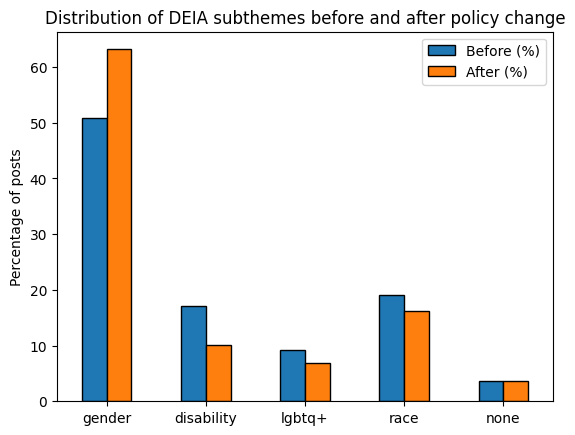

In [20]:
subtheme_comparison.plot(
    kind="bar",
    edgecolor="black"
)

plt.ylabel("Percentage of posts")
plt.title("Distribution of DEIA subthemes before and after policy change")
plt.xticks(rotation=0)
plt.show()

In [21]:
before.columns

Index(['ID', 'Date', 'Subreddit', 'Permalink', 'Score', 'num_comment',
       'DEIA?_x', 'KeyWords_x', 'SubTheme_x', 'Position_x',
       'Confidence level_x', 'Justification_x', 'DEIA?_y', 'KeyWords_y',
       'SubTheme_y', 'Position_y', 'Confidence level_y', 'Justification_y',
       'IS_DEIA?', 'Agreement_Polarization', 'Agreement_Subthemes', 'gender',
       'disability', 'lgbtq+', 'race', 'none'],
      dtype='str')

In [22]:
policy_date = pd.Timestamp("2025-01-20", tz="UTC")

window_days = 7
during_start = policy_date - pd.Timedelta(days=window_days)
during_end = policy_date + pd.Timedelta(days=window_days)

# separar períodos
before = manual_labeling_dataset[
    manual_labeling_dataset["Date"] < during_start
]

during = manual_labeling_dataset[
    (manual_labeling_dataset["Date"] >= during_start) &
    (manual_labeling_dataset["Date"] <= during_end)
]

after = manual_labeling_dataset[
    manual_labeling_dataset["Date"] > during_end
]

# contagem (somar colunas binárias)
before_counts = before[subthemes].sum()
during_counts = during[subthemes].sum()
after_counts = after[subthemes].sum()

# juntar em dataframe
subtheme_comparison = pd.DataFrame({
    "Before Policy": before_counts,
    "During Policy": during_counts,
    "After Policy": after_counts
})

# normalizar por coluna (cada coluna soma 1)
subtheme_comparison = subtheme_comparison.div(
    subtheme_comparison.sum(axis=0),
    axis=1
)

subtheme_comparison.to_excel(results_path / "subthemes" / "subtheme_comparison.xlsx", index=True)

subtheme_comparison = subtheme_comparison.round(2) * 100
subtheme_comparison.columns = ["Before Policy (%)", "During Policy (%)", "After Policy (%)"]
print(subtheme_comparison)

            Before Policy (%)  During Policy (%)  After Policy (%)
gender                   51.0               65.0              63.0
disability               17.0               12.0              10.0
lgbtq+                    9.0                8.0               7.0
race                     19.0               15.0              16.0
none                      4.0                0.0               4.0


In [23]:
policy_date = pd.Timestamp("2025-01-20", tz="UTC")

window_days = 7
during_start = policy_date - pd.Timedelta(days=window_days)
during_end = policy_date + pd.Timedelta(days=window_days)

# separar períodos
before = manual_labeling_dataset[
    manual_labeling_dataset["Date"] < during_start
]

during = manual_labeling_dataset[
    (manual_labeling_dataset["Date"] >= during_start) &
    (manual_labeling_dataset["Date"] <= during_end)
]

after = manual_labeling_dataset[
    manual_labeling_dataset["Date"] > during_end
]

# contagem (somar colunas binárias)
before_counts = before[subthemes].sum()
during_counts = during[subthemes].sum()
after_counts = after[subthemes].sum()

# juntar em um dataframe
subtheme_comparison = pd.DataFrame({
    "Before Policy": before_counts,
    "During Policy": during_counts,
    "After Policy": after_counts
})

# normalizar por linha (cada subtema soma 1)
subtheme_comparison = subtheme_comparison.div(
    subtheme_comparison.sum(axis=1),
    axis=0
)

print(subtheme_comparison)

            Before Policy  During Policy  After Policy
gender           0.609982       0.031423      0.358595
disability       0.765517       0.020690      0.213793
lgbtq+           0.722892       0.024096      0.253012
race             0.696629       0.022472      0.280899
none             0.685714       0.000000      0.314286

### Subreddits comparison

In [24]:
before_subthemes = before.groupby("Subreddit").size()
after_subthemes = after.groupby("Subreddit").size()

before_column = before_subthemes / before_subthemes.sum()
after_column = after_subthemes / after_subthemes.sum()

index = before_column.index 
columns = ["Before Policy", "After Policy"]

subthemes_comparison = pd.DataFrame({
    "Before Policy (%)": before_column.fillna(0).round(2) * 100,
    "After Policy (%)": after_column.fillna(0).round(2) * 100
}, index=index)

# subthemes_comparison.fillna(0, inplace=True)
print(subthemes_comparison)

                   Before Policy (%)  After Policy (%)
Subreddit                                             
ExperiencedDevs                  5.0               2.0
cscareerquestions               33.0               7.0
girlsgonewired                  38.0               1.0
womenintech                     24.0              90.0


## LLm Ability to capture temporal changes

In [ ]:
from scipy.stats import pearsonr

models_names = [
    "Llama",
]

results_path = Path("llm_results_public")

def load_results(model_name: str) -> pd.DataFrame:
    file_path = results_path / f"PANDEIA_RESULTS_{model_name}_fewshot.csv"
    return pd.read_csv(file_path)

llama_faltante = pd.read_csv(results_path / "PANDEIA_RESULTS_Llama_faltante.csv")

datasets = {}

for i in range(len(models_names)):
    datasets[models_names[i]] = load_results(models_names[i])

mask = datasets['Llama']['ID'] == llama_faltante['ID'].iloc[0]
datasets['Llama'].loc[mask, :] = llama_faltante.loc[0, datasets['Llama'].columns].values


dataset_size = datasets[models_names[0]].shape[0]

In [26]:
llama = datasets['Llama'][datasets['Llama']['ID'].isin(manual_labeling_dataset['ID'].to_list())]

#### Processing the JSON:

In [27]:
VALID_CLASSES = {"pro-DEIA", "anti-DEIA", "neutral"}

mapping = {
    "pro-DEIA": "Pro-DEIA",
    "anti-DEIA": "Anti-DEIA",
    "neutral": "Neutral"
}

def normalize_polarization(value):

    if not value:
        return "None"

    value = value.strip()

    if value in VALID_CLASSES:
        return mapping[value]

    return "None"

def polarization_parsing_eda(df, column_name):

    records = []

    for idx, row in df.iterrows():

        diagnosis = diagnose_json(row[column_name])

        polarization_norm = normalize_polarization(
            diagnosis["polarization"]
        )

        record = {
            "row_id": idx,
            "valid_json": diagnosis["valid_json"],
            "error_type": diagnosis["error_type"],
            "error_message": diagnosis["error_message"],
            "polarization_raw": diagnosis["polarization"],
            "polarization_normalized": polarization_norm,
            "raw_preview": diagnosis["raw_preview"]
        }

        records.append(record)

    return pd.DataFrame(records)

def diagnose_json(text: str):
    """
    Try to extract JSON from the given text and parse the "polarization" field.
    """

    result = {
        "polarization": None,
        "valid_json": False,
        "error_type": None,
        "error_message": None,
        "raw_preview": str(text)[:200]
    }

    if not text or not isinstance(text, str):
        result["error_type"] = "non_string"
        return result

    # remove markdown
    text = re.sub(r"```json|```", "", text)

    start = text.find("{")
    if start == -1:
        result["error_type"] = "no_json_found"
        return result

    brace_count = 0
    json_str = None

    for i in range(start, len(text)):
        if text[i] == "{":
            brace_count += 1
        elif text[i] == "}":
            brace_count -= 1

        if brace_count == 0:
            json_str = text[start:i+1]
            break

    if json_str is None:
        result["error_type"] = "unbalanced_braces"
        return result

    try:
        parsed = json.loads(json_str)

        result["valid_json"] = True
        result["polarization"] = parsed.get("polarization", None)

    except json.JSONDecodeError as e:

        result["error_type"] = "json_decode_error"
        result["error_message"] = str(e)

    return result

In [28]:
def extract_first_json(text: str):
    if not text or type(text) != str:
        return {"polarization": "JSON Inválido"}
    # remove markdown
    text = re.sub(r"```json|```", "", text)

    start = text.find("{")
    if start == -1:
        return {"polarization": "JSON Inválido"}

    brace_count = 0

    for i in range(start, len(text)):
        if text[i] == "{":
            brace_count += 1
        elif text[i] == "}":
            brace_count -= 1

        if brace_count == 0:
            json_str = text[start:i+1]
            break
    else:
        return {"polarization": "JSON Inválido"}

    # tentativa de parse
    try:
        return json.loads(json_str)
    except json.JSONDecodeError:
        # correções comuns
        return {"polarization": "JSON Inválido"}

def extract_polarization_pipeline(df, column_name):
    """
    Complete pipeline:
    1. Extract JSON from LLM output
    2. Get the polarization field
    3. Normalize the class
    """

    results = []

    for _, row in df.iterrows():

        parsed = extract_first_json(row[column_name])

        polarization = parsed.get("polarization", None)

        polarization = normalize_polarization(polarization)

        results.append(polarization)

    return results

In [29]:
llama["polarization_class_oneshot"] = extract_polarization_pipeline(
            llama,
            "polarization_oneshot"
        )

#### Comparison LLM vs Manual

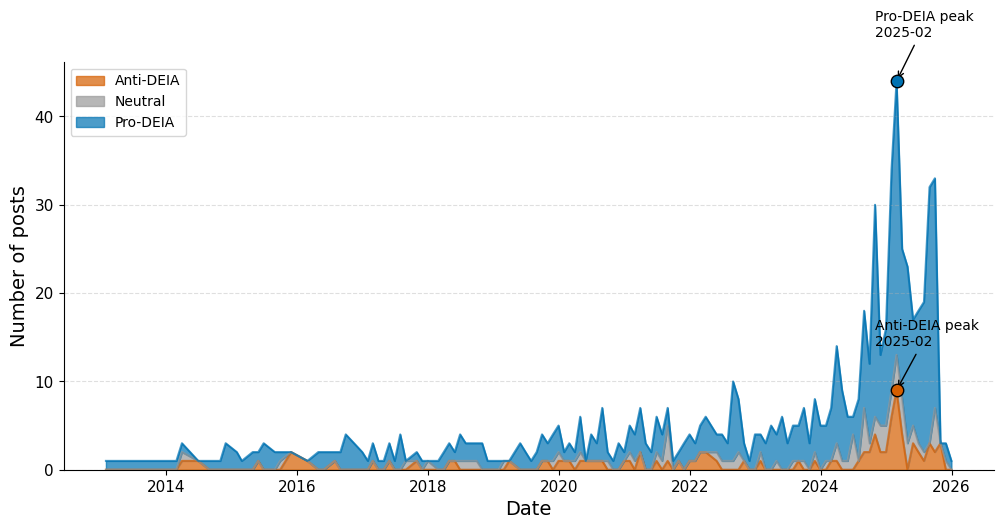

In [30]:
llama["Date"] = pd.to_datetime(llama["Date"])

polarization_time = (
    llama
    .groupby([pd.Grouper(key="Date", freq="ME"), "polarization_class_oneshot"])
    .size()
    .unstack(fill_value=0)
)

# garantir ordem consistente das colunas
polarization_time = polarization_time[["Anti-DEIA", "Neutral", "Pro-DEIA"]]

# picos
peak_date_pro = polarization_time["Pro-DEIA"].idxmax()
peak_value_pro = polarization_time["Pro-DEIA"].max()

peak_date_anti = polarization_time["Anti-DEIA"].idxmax()
peak_value_anti = polarization_time["Anti-DEIA"].max()

ax = polarization_time.plot.area(
    color=["#D55E00", "#999999", "#0072B2"],
    alpha=0.7,
    figsize=(12, 6)
)

# posição vertical correta no stacked area
y_pro = polarization_time.loc[peak_date_pro].sum()
y_anti = polarization_time.loc[peak_date_anti, "Anti-DEIA"]

# pontos nos picos
ax.scatter(
    peak_date_pro,
    y_pro,
    color="#0072B2",
    edgecolor="black",
    zorder=5,
    s=80,
    # label="Peak Pro-DEIA"
)

ax.scatter(
    peak_date_anti,
    y_anti,
    color="#D55E00",
    edgecolor="black",
    zorder=5,
    s=80,
    # label="Peak Anti-DEIA"
)

# anotações
ax.annotate(
    f"Pro-DEIA peak\n{peak_date_pro.strftime('%Y-%m')}",
    xy=(peak_date_pro, y_pro),
    xytext=(peak_date_pro - pd.Timedelta(days=120), y_pro + 5),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

ax.annotate(
    f"Anti-DEIA peak\n{peak_date_anti.strftime('%Y-%m')}",
    xy=(peak_date_anti, y_anti),
    xytext=(peak_date_anti - pd.Timedelta(days=120), y_anti + 5),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.xticks(rotation=0)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

for label in ax.get_xticklabels():
    label.set_ha("center")

plt.ylabel("Number of posts", fontdict={"size": 14})
plt.xlabel("Date", fontdict={"size": 14})

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend()

plt.savefig(
    figures_path / "polarization_over_time_llama.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

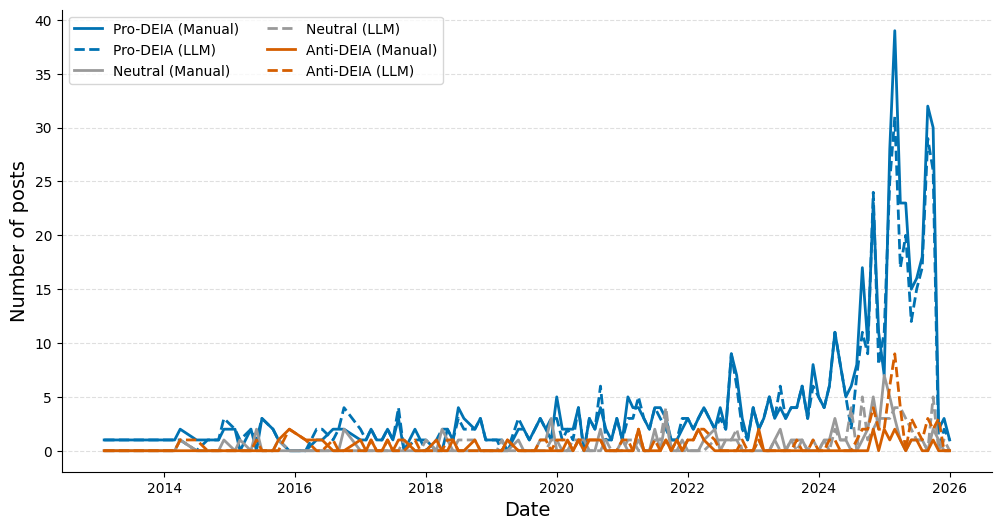

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# 1. PREPARAR MANUAL
# =====================
manual_labeling_dataset["Date"] = pd.to_datetime(manual_labeling_dataset["Date"], utc=True)

manual_time = (
    manual_labeling_dataset
    .groupby([pd.Grouper(key="Date", freq="ME"), "Agreement_Polarization"])
    .size()
    .unstack(fill_value=0)
)

manual_time = manual_time[["Anti-DEIA", "Neutral", "Pro-DEIA"]]

# =====================
# 2. PREPARAR LLM (LLAMA)
# =====================
llama["Date"] = pd.to_datetime(llama["Date"])

llm_time = (
    llama
    .groupby([pd.Grouper(key="Date", freq="ME"), "polarization_class_oneshot"])
    .size()
    .unstack(fill_value=0)
)

llm_time = llm_time[["Anti-DEIA", "Neutral", "Pro-DEIA"]]

# =====================
# 3. ALINHAR DATAS
# =====================
# importante para garantir comparação correta
common_index = manual_time.index.union(llm_time.index)

manual_time = manual_time.reindex(common_index, fill_value=0)
llm_time = llm_time.reindex(common_index, fill_value=0)

# =====================
# 4. PLOT
# =====================
plt.figure(figsize=(12, 6))

colors = {
    "Pro-DEIA": "#0072B2",
    "Neutral": "#999999",
    "Anti-DEIA": "#D55E00"
}

for cls in ["Pro-DEIA", "Neutral", "Anti-DEIA"]:

    # manual (linha sólida)
    plt.plot(
        manual_time.index,
        manual_time[cls],
        label=f"{cls} (Manual)",
        color=colors[cls],
        linewidth=2
    )

    # LLM (linha tracejada)
    plt.plot(
        llm_time.index,
        llm_time[cls],
        label=f"{cls} (LLM)",
        color=colors[cls],
        linestyle="--",
        linewidth=2
    )

# =====================
# 5. ESTILO
# =====================
plt.xlabel("Date", fontsize=14)
plt.ylabel("Number of posts", fontsize=14)

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(ncol=2, fontsize=10)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =====================
# 6. SALVAR
# =====================
plt.savefig(
    figures_path / "polarization_over_time_comparison.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [32]:
stat, pvalue = pearsonr(
    manual_time["Pro-DEIA"],
    llm_time["Pro-DEIA"]
)

print(f"Pearson correlation (Pro-DEIA): {stat:.4f}, p-value: {pvalue:.4e}")

stat, pvalue = pearsonr(
    manual_time["Anti-DEIA"],
    llm_time["Anti-DEIA"]
)

print(f"Pearson correlation (Anti-DEIA): {stat:.4f}, p-value: {pvalue:.4e}")

stat, pvalue = pearsonr(
    manual_time["Neutral"],
    llm_time["Neutral"]
)

print(f"Pearson correlation (Neutral): {stat:.4f}, p-value: {pvalue:.4e}")

Pearson correlation (Pro-DEIA): 0.9820, p-value: 6.8462e-91
Pearson correlation (Anti-DEIA): 0.5284, p-value: 2.3931e-10
Pearson correlation (Neutral): 0.5003, p-value: 2.8272e-09


In [33]:
mae = np.mean(np.abs(manual_time["Pro-DEIA"] - llm_time["Pro-DEIA"]))
mse = np.mean((manual_time["Pro-DEIA"] - llm_time["Pro-DEIA"]) ** 2)

print(f"Mean Absolute Error (Pro-DEIA): {mae:.4f}")
print(f"Mean Squared Error (Pro-DEIA): {mse:.4f}")

Mean Absolute Error (Pro-DEIA): 0.7920
Mean Squared Error (Pro-DEIA): 2.3920


In [34]:
# kl divergence
from scipy.stats import entropy

# para evitar divisão por zero, adicionamos uma pequena constante
manual_pct = manual_time.div(manual_time.sum(axis=1), axis=0)
llm_pct = llm_time.div(llm_time.sum(axis=1), axis=0)

epsilon = 1e-10

manual_pct = manual_pct + epsilon
llm_pct = llm_pct + epsilon

import numpy as np

kl_values = []

for date in manual_pct.index:
    p = manual_pct.loc[date].values
    q = llm_pct.loc[date].values

    kl = np.sum(p * np.log(p / q))
    kl_values.append(kl)

kl_series = pd.Series(kl_values, index=manual_pct.index)

In [35]:
kl_series.mean()

np.float64(3.1027251146681905)

In [36]:
kl_series.max()

np.float64(23.025850930040455)

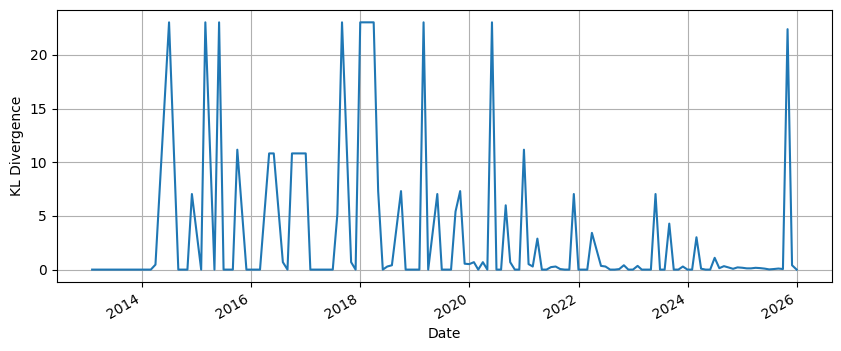

In [37]:
kl_series.plot(figsize=(10,4))
plt.ylabel("KL Divergence")
plt.xlabel("Date")
plt.grid()
plt.show()